## **Assignment Three (EECS3405 F25)**

**your name (your student number):** Karen Lau (--)

**your yorku email:** --

This assignment is mainly for you to review review neural networks and deep learning models. You have to work individually. Remember to fill in your information (name, student number, email) at above.


##**What to Submit**

Use **one** notebook file (*.ipynb*) for **each** question, which should contain all of your answers and codes. You must zip all three notebooks into one zip file to submit it onto eClass.
No late submission will be accepted.

* For all written parts, write your answers in text cells. To avoid confusions in marking, better to embed latex codes there to represent all mathematical notations and equations.  No handwriting is accepted.

* For programming parts, you should give codes, comments, explanations and the proper running outputs in both code and text cells. Make your jupyter notebook clean and concise. Remove all unused codes and all intermediate results from the submitted notebook. The submitted notebook should include only the final (best) outputs for each question. Also make sure every code cell runnable so that markers can reproduce the outputs if necessary.

### **Q1** (20 marks) **Matrix Factorization for Collaborative Filtering**

We investigate matrix factorization for collaborative filtering using [the MovieLens 100K dataset]( https://grouplens.org/datasets/movielens/100k/), which contains 100,000 ratings provided by 943 users on 1,682 movies.
In this question, you will first follow the given code to download the MovieLens 100K ratings and load them into a Python sparse matrix. After that, refer to [this matrix factorization implementation](https://colab.research.google.com/drive/1WVEKcaHB858WsdmjQ1MOjyH2G92TDveF) to factorize the user–movie rating matrix for recommendation purposes (do NOT use `jax.grad` here).
Once the factorization is complete, use the cosine similarity between movie vectors, defined as

$$
\text{sim}(\mathbf{v}_i,\mathbf{v}_j) = \frac{\mathbf{v}_i \cdot \mathbf{v}_j}{\Vert \mathbf{v}_i \Vert \Vert \mathbf{v}_j \Vert}
$$
to measure the similarity between different movies.

As an example, you may recommend the top three most similar movies for each of the following movie IDs:

$$
\Big\{0, 94, 250, 379, 784, 863, 1044, 1141, 1203, 1445 \Big\}
$$

You may refer to [the movie list](http://www.cs.yorku.ca/~huijiang/ml-100k/u.item) for the corresponding movie titles.
(Note: the indexes in the list start from 1, not 0.)

*   Use both Stochastic Gradient Descent (SGD) and the Alternating algorithm for matrix factorization. Compare their performance in terms of training speed and recommendation quality.
* Evaluate how the movie vector dimension size $k=10, 30, 100$
affects both the training efficiency and the quality of recommendations.






In [ ]:
## Preparation code to download the data and load them into a sparse matrix
##
import pandas as pd
import numpy as np
import gdown
from scipy.sparse import csr_matrix

# 1. Download and unzip the dataset first
#    URL: https://files.grouplens.org/datasets/movielens/ml-100k.zip
#    Then point to the u.data file inside the unzipped folder.
#!wget -O ml-100k.zip https://files.grouplens.org/datasets/movielens/ml-100k.zip
#!unzip -o -q ml-100k.zip
#path = "ml-100k/u.data"

##download from google drive
#url = 'https://drive.google.com/file/d/12cpRJ2977nyqUSiUMkvdRS9OtYy6Fj_P/view?usp=share_link'
#path = 'u.data'
#gdown.download(url, path, quiet=False,fuzzy=True)

# download from YorkU server
!wget -q -r -np -nH --cut-dirs=1 -R "index.html*" http://www.cs.yorku.ca/~huijiang/ml-100k/
path = "ml-100k/u.data"

# The raw file is tab-separated: user_id, item_id, rating, timestamp

df = pd.read_csv(path, sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

# 2. Convert IDs to 0-based indices (good for matrix indexing)
df['user_id'] = df['user_id'].astype('category')
df['item_id'] = df['item_id'].astype('category')

n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()

print(f"Users: {n_users}, Items: {n_items}, Ratings: {len(df)}")

# 3. Build a sparse user–item rating matrix (CSR format)
# Rows → users, Columns → items, Values → ratings
X = csr_matrix(
    (df['rating'].astype(float),
     (df['user_id'].cat.codes, df['item_id'].cat.codes)),
    shape=(n_users, n_items)
)

print(X.shape)

Users: 943, Items: 1682, Ratings: 100000
(943, 1682)


In lecture we discussed that the loss function $Q(\mathbf{U}, \mathbf{V})$ is as follows:
$$
Q(\mathbf{U}, \mathbf{V}) = \frac{1}{|\Omega|}\sum_{\forall (i,j) \in \Omega} \Big(x_{ij}-\mathbf{u}_i^\intercal \mathbf{v}_j \Big)^2 + \frac{\lambda_1}{|\mathbf{U}|} \sum_{i} || \mathbf{u}_i ||^2
+ \frac{\lambda_2}{|\mathbf{V}|} \sum_{j} || \mathbf{v}_j ||^2
$$

In [ ]:
# vectorized version of loss function Q(U,V) as above
# X: a sparse matrix (scipy.sparse.csr_matrix)
# U,V: both dense matrices (X = U @ V.T)
def loss_fun_vec(U, V, X, lambda1=0.1, lambda2=0.1):
  ind = X.nonzero()
  diff = np.sum(U[ind[0],:]*V[ind[1],:],axis=1) - np.array(X[ind[0],ind[1]]).squeeze()
  loss = np.mean(diff*diff)
  loss += lambda1*np.sum(U*U)/U.size + lambda2*np.sum(V*V)/V.size

  return loss

In [ ]:
import time

In [ ]:
### Alternating Algorithm for Matrix Factorization (Algorithm 7.6 on page 145)
###
# X: a sparse matrix (scipy.sparse.csr_matrix)
# k: size for dense vectors
def Alternating_MF(X, k=10, lambda1=0.1, lambda2=0.1, max_epoch=10):
  # initialize U and V
  U = 0.01*np.random.normal(size =(X.shape[0], k))
  V = 0.01*np.random.normal(size =(X.shape[1], k))
  n = X.count_nonzero()       # number of training samples

  loss = loss_fun_vec(U, V, X, lambda1, lambda2)
  print(f'epoch = 0: loss = {loss}')

  for ep in range(max_epoch):
    start_time = time.time()

    for i in range(X.shape[0]):
      X_row = X.getrow(i)     # extract i-th row in X
      ind = X_row.nonzero()   # get 1st,2nd indices for i-th col in X
      V_s = V[ind[1],:]
      U[i,:] = np.transpose(np.linalg.inv(V_s.T @ V_s + lambda1 * np.identity(k) * n/U.size) @ V_s.T @ X_row[ind[0],ind[1]].T)

    for j in range(X.shape[1]):
      X_col = X.getcol(j)     # extract j-th col in X
      ind = X_col.nonzero()   # get 1st,2nd indices for i-th col in X
      U_s = U[ind[0],:]
      V[j,:] = np.transpose(np.linalg.inv(U_s.T @ U_s + lambda2 * np.identity(k) * n/V.size) @ U_s.T @ X_col[ind[0],ind[1]].T)

    end_time = time.time()

    loss = loss_fun_vec(U, V, X, lambda1, lambda2)
    print(f'epoch = {ep+1}: loss = {loss}, time = {end_time - start_time:.2f} sec')

  return U,V

In [ ]:
print(X.shape)

U10,V10 = Alternating_MF(X,k=10)

print(U10.shape,V10.shape)

(943, 1682)
epoch = 0: loss = 13.727054868981094
epoch = 1: loss = 4.29720847495233, time = 1.81 sec
epoch = 2: loss = 0.7351225673555158, time = 2.58 sec
epoch = 3: loss = 0.6635107761584161, time = 1.00 sec
epoch = 4: loss = 0.6387187089964453, time = 1.42 sec
epoch = 5: loss = 0.625074507284611, time = 1.48 sec
epoch = 6: loss = 0.6161500776075337, time = 0.99 sec
epoch = 7: loss = 0.6097181789113809, time = 1.00 sec
epoch = 8: loss = 0.6048583303796548, time = 0.98 sec
epoch = 9: loss = 0.6010991837383799, time = 0.99 sec
epoch = 10: loss = 0.5981103699164282, time = 0.97 sec
(943, 10) (1682, 10)


In [ ]:
movie_ids = [0, 94, 250, 379, 784, 863, 1044, 1141, 1203, 1445]
V_select10 = V10[movie_ids]
norms10 = np.linalg.norm(V_select10, axis=1, keepdims=True)
V_norm10 = V_select10/norms10

sim_mat10 = V_norm10 @ V_norm10.T
sim_mat101 = np.round(sim_mat10,3)
print(sim_mat101)

[[1.    0.982 0.899 0.893 0.791 0.74  0.79  0.743 0.657 0.632]
 [0.982 1.    0.839 0.884 0.793 0.721 0.764 0.745 0.623 0.61 ]
 [0.899 0.839 1.    0.741 0.779 0.615 0.859 0.613 0.652 0.52 ]
 [0.893 0.884 0.741 1.    0.727 0.89  0.686 0.647 0.624 0.805]
 [0.791 0.793 0.779 0.727 1.    0.789 0.532 0.681 0.662 0.6  ]
 [0.74  0.721 0.615 0.89  0.789 1.    0.532 0.606 0.693 0.887]
 [0.79  0.764 0.859 0.686 0.532 0.532 1.    0.496 0.603 0.508]
 [0.743 0.745 0.613 0.647 0.681 0.606 0.496 1.    0.704 0.38 ]
 [0.657 0.623 0.652 0.624 0.662 0.693 0.603 0.704 1.    0.677]
 [0.632 0.61  0.52  0.805 0.6   0.887 0.508 0.38  0.677 1.   ]]


In [ ]:
for i, movie_id in enumerate(movie_ids):
    sims = sim_mat10[i]
    # Exclude self
    top_indices = sims.argsort()[::-1][1:4]  # top-3 similar movies
    top_movie_ids = [movie_ids[j] for j in top_indices]
    print(f"Movie {movie_id} most similar: {top_movie_ids}")


Movie 0 most similar: [94, 250, 379]
Movie 94 most similar: [0, 379, 250]
Movie 250 most similar: [0, 1044, 94]
Movie 379 most similar: [0, 863, 94]
Movie 784 most similar: [94, 0, 863]
Movie 863 most similar: [379, 1445, 784]
Movie 1044 most similar: [250, 0, 94]
Movie 1141 most similar: [94, 0, 1203]
Movie 1203 most similar: [1141, 863, 1445]
Movie 1445 most similar: [863, 379, 1203]


In [ ]:
print(X.shape)

U30,V30 = Alternating_MF(X,k=30)

print(U30.shape,V30.shape)

(943, 1682)
epoch = 0: loss = 13.727059114291503
epoch = 1: loss = 2.0971383012382194, time = 3.30 sec
epoch = 2: loss = 0.4637705419987833, time = 2.38 sec
epoch = 3: loss = 0.38411913929164015, time = 2.34 sec
epoch = 4: loss = 0.34962592071656606, time = 2.06 sec
epoch = 5: loss = 0.32861838000279336, time = 1.96 sec
epoch = 6: loss = 0.3141668814855305, time = 3.06 sec
epoch = 7: loss = 0.30338968823235024, time = 2.08 sec
epoch = 8: loss = 0.2949035891316658, time = 2.21 sec
epoch = 9: loss = 0.28799812240041595, time = 1.41 sec
epoch = 10: loss = 0.2822384114577037, time = 1.32 sec
(943, 30) (1682, 30)


In [ ]:
V_select30 = V30[movie_ids]
norms30 = np.linalg.norm(V_select30, axis=1, keepdims=True)
V_norm30 = V_select30/norms30

sim_mat30 = V_norm30 @ V_norm30.T
sim_mat301 = np.round(sim_mat30,3)
print(sim_mat301)

[[ 1.     0.568  0.243  0.481  0.186  0.163  0.178  0.2    0.368  0.189]
 [ 0.568  1.     0.209  0.495  0.126  0.217  0.199  0.226  0.436  0.038]
 [ 0.243  0.209  1.     0.151  0.182 -0.008  0.199  0.391  0.101  0.136]
 [ 0.481  0.495  0.151  1.     0.326  0.401  0.227  0.452  0.351  0.25 ]
 [ 0.186  0.126  0.182  0.326  1.     0.593  0.08   0.204  0.07   0.265]
 [ 0.163  0.217 -0.008  0.401  0.593  1.     0.189  0.274  0.311  0.235]
 [ 0.178  0.199  0.199  0.227  0.08   0.189  1.     0.413  0.227 -0.172]
 [ 0.2    0.226  0.391  0.452  0.204  0.274  0.413  1.     0.126  0.147]
 [ 0.368  0.436  0.101  0.351  0.07   0.311  0.227  0.126  1.     0.129]
 [ 0.189  0.038  0.136  0.25   0.265  0.235 -0.172  0.147  0.129  1.   ]]


In [ ]:
for i, movie_id in enumerate(movie_ids):
    sims = sim_mat30[i]
    # Exclude self
    top_indices = sims.argsort()[::-1][1:4]  # top-3 similar movies
    top_movie_ids = [movie_ids[j] for j in top_indices]
    print(f"Movie {movie_id} most similar: {top_movie_ids}")


Movie 0 most similar: [94, 379, 1203]
Movie 94 most similar: [0, 379, 1203]
Movie 250 most similar: [1141, 0, 94]
Movie 379 most similar: [94, 0, 1141]
Movie 784 most similar: [863, 379, 1445]
Movie 863 most similar: [784, 379, 1203]
Movie 1044 most similar: [1141, 1203, 379]
Movie 1141 most similar: [379, 1044, 250]
Movie 1203 most similar: [94, 0, 379]
Movie 1445 most similar: [784, 379, 863]


In [ ]:
print(X.shape)

U100,V100 = Alternating_MF(X,k=100)

print(U100.shape,V100.shape)

(943, 1682)
epoch = 0: loss = 13.727026238911417
epoch = 1: loss = 1.3480809221051753, time = 3.13 sec
epoch = 2: loss = 0.48189075260291636, time = 4.56 sec
epoch = 3: loss = 0.3365464540915901, time = 2.86 sec
epoch = 4: loss = 0.2734323774790783, time = 3.04 sec
epoch = 5: loss = 0.2372565734909335, time = 4.82 sec
epoch = 6: loss = 0.2130819893321358, time = 2.87 sec
epoch = 7: loss = 0.19537602009594524, time = 2.88 sec
epoch = 8: loss = 0.18163252586487363, time = 2.87 sec
epoch = 9: loss = 0.1705169704487917, time = 4.87 sec
epoch = 10: loss = 0.16124482930400222, time = 2.89 sec
(943, 100) (1682, 100)


In [ ]:
V_select100 = V100[movie_ids]
norms100 = np.linalg.norm(V_select100, axis=1, keepdims=True)
V_norm100 = V_select100/norms100

sim_mat100 = V_norm100 @ V_norm100.T
sim_mat1001 = np.round(sim_mat100,3)
print(sim_mat1001)

[[ 1.     0.203  0.219  0.006  0.017 -0.12   0.063  0.234  0.231  0.101]
 [ 0.203  1.     0.112 -0.029  0.088  0.202  0.204  0.111  0.2    0.057]
 [ 0.219  0.112  1.    -0.133  0.183  0.238  0.279  0.422  0.353  0.048]
 [ 0.006 -0.029 -0.133  1.     0.079 -0.052 -0.028 -0.037 -0.022  0.127]
 [ 0.017  0.088  0.183  0.079  1.     0.047  0.058  0.183  0.367  0.027]
 [-0.12   0.202  0.238 -0.052  0.047  1.     0.156  0.219  0.133  0.149]
 [ 0.063  0.204  0.279 -0.028  0.058  0.156  1.     0.291  0.172  0.264]
 [ 0.234  0.111  0.422 -0.037  0.183  0.219  0.291  1.     0.369  0.065]
 [ 0.231  0.2    0.353 -0.022  0.367  0.133  0.172  0.369  1.     0.111]
 [ 0.101  0.057  0.048  0.127  0.027  0.149  0.264  0.065  0.111  1.   ]]


In [ ]:
for i, movie_id in enumerate(movie_ids):
    sims = sim_mat100[i]
    # Exclude self
    top_indices = sims.argsort()[::-1][1:4]  # top-3 similar movies
    top_movie_ids = [movie_ids[j] for j in top_indices]
    print(f"Movie {movie_id} most similar: {top_movie_ids}")


Movie 0 most similar: [1141, 1203, 250]
Movie 94 most similar: [1044, 0, 863]
Movie 250 most similar: [1141, 1203, 1044]
Movie 379 most similar: [1445, 784, 0]
Movie 784 most similar: [1203, 1141, 250]
Movie 863 most similar: [250, 1141, 94]
Movie 1044 most similar: [1141, 250, 1445]
Movie 1141 most similar: [250, 1203, 1044]
Movie 1203 most similar: [1141, 784, 250]
Movie 1445 most similar: [1044, 863, 379]


## Now we will try the SGD Approach

As seen in the lab 8 colab, the formula to compute the gradient for the loss function of one mini-batch is:

$$
Q(\mathbf{U}, \mathbf{V}) = \frac{1}{|B|}\sum_{\forall (i,j) \in \Omega} \Big(x_{ij}-\mathbf{u}_i^\intercal \mathbf{v}_j \Big)^2 + \frac{\lambda_1}{|\mathbf{U}|} \sum_{i} || \mathbf{u}_i ||^2
+ \frac{\lambda_2}{|\mathbf{V}|} \sum_{j} || \mathbf{v}_j ||^2
$$

where $|B|$ denotes the mini-batch size, and $|\mathbf{U}|$ and $|\mathbf{V}|$ stand for the number of elements in matrics $\mathbf{U}$ and $\mathbf{V}$.


For all $i$ in $B$,
$$
\frac{\partial Q}{\partial \mathbf{u}_i } = \frac{1}{|B|} \sum_{\forall j, with (i,j) \in B}
2 \big( \mathbf{u}_i^\intercal \mathbf{v}_j - x_{ij} \big) \mathbf{v}_j  + 2 \frac{\lambda_1}{|\mathbf{U}|} \mathbf{u}_i
$$

For all $j$ in $B$,
$$
\frac{\partial Q}{\partial \mathbf{v}_j } = \frac{1}{|B|} \sum_{\forall i, with (i,j) \in B}
2 \big(\mathbf{u}_i^\intercal \mathbf{v}_j - x_{ij} \big) \mathbf{u}_i  + 2 \frac{\lambda_2}{|\mathbf{V}|} \mathbf{v}_j
$$

In [ ]:
# use numpy to implement the code to compute the gradient from sractch as above
import numpy as np

def my_grad(U, V, X_batch, lambda1=0.1, lambda2=0.1):
  U_grad = np.zeros_like(U)
  V_grad = np.zeros_like(V)
  ind = X_batch.nonzero()
  n = X_batch.count_nonzero()

  diff = np.sum(U[ind[0],:]*V[ind[1],:],axis=1) - np.array(X[ind[0],ind[1]]).squeeze()
  for i in range(n):
    U_grad[ind[0][i],:] += 2.0*diff[i]*V[ind[1][i],:]/n + 2.0*lambda1*U[ind[0][i],:]/U.size
    V_grad[ind[1][i],:] += 2.0*diff[i]*U[ind[0][i],:]/n + 2.0*lambda2*V[ind[1][i],:]/V.size

  return U_grad,V_grad

In [ ]:
### Stochastic Gradient Descent for Matrix Factorization
# use my_grad() to compute the gradient automatically
#
import numpy as np
import scipy.sparse as sparse

# X: a sparse matrix (scipy.sparse.csr_matrix)
# k: size for dense vectors
def SGD_MF(X, k=10, batch_size=100, lambda1=0.01, lambda2=0.01, max_epoch=10, lr=0.1):
  # initialize U and V
  U = 0.01*np.random.normal(size =(X.shape[0], k))
  V = 0.01*np.random.normal(size =(X.shape[1], k))
  X_index = X.nonzero()

  loss = loss_fun_vec(U, V, X, lambda1, lambda2)
  print(f'epoch = 0: loss = {loss}')

  for ep in range(max_epoch):
    n = X.count_nonzero()
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, batch_size):
      batch_indices = indices[batch_start:batch_start+batch_size]
      X_data = np.squeeze(np.array(X[X_index[0][batch_indices], X_index[1][batch_indices]]))
      X_batch = sparse.csr_matrix((X_data,(X_index[0][batch_indices],X_index[1][batch_indices])),shape=X.shape)

      [U_grad, V_grad] = my_grad(U,V,X_batch)
      U -= lr * U_grad
      V -= lr * V_grad

    loss = loss_fun_vec(U, V, X, lambda1, lambda2)
    print(f'epoch = {ep+1}: loss = {loss}')

  return U,V

In [ ]:
start_time = time.time()
U_sgd10, V_sgd10 = SGD_MF(X, k=10, batch_size=500, max_epoch=40, lr=0.5)
end_time = time.time()

total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")


epoch = 0: loss = 13.727041791531521
epoch = 1: loss = 13.726884461175509
epoch = 2: loss = 13.725848666859884
epoch = 3: loss = 13.713760366068248
epoch = 4: loss = 13.564172864812061
epoch = 5: loss = 11.98866390125261
epoch = 6: loss = 6.505469762536573
epoch = 7: loss = 3.5244856858267783
epoch = 8: loss = 2.376313977876035
epoch = 9: loss = 1.8215855723008996
epoch = 10: loss = 1.5180032977638658
epoch = 11: loss = 1.3360430677323072
epoch = 12: loss = 1.219117118504536
epoch = 13: loss = 1.1399322462597332
epoch = 14: loss = 1.0839859912850274
epoch = 15: loss = 1.0432141665348365
epoch = 16: loss = 1.01240117321631
epoch = 17: loss = 0.9886985536988704
epoch = 18: loss = 0.9696853012358936
epoch = 19: loss = 0.9548675526486107
epoch = 20: loss = 0.9424881768333778
epoch = 21: loss = 0.9321959223094535
epoch = 22: loss = 0.9235091716394102
epoch = 23: loss = 0.9162422020923756
epoch = 24: loss = 0.9098677343342385
epoch = 25: loss = 0.9042266886064992
epoch = 26: loss = 0.8992170

In [ ]:
movie_ids = [0, 94, 250, 379, 784, 863, 1044, 1141, 1203, 1445]
V_select10sgd = V_sgd10[movie_ids]
norms10sgd = np.linalg.norm(V_select10sgd, axis=1, keepdims=True)
V_norm10sgd = V_select10sgd/norms10sgd

sim_mat10sgd = V_norm10sgd @ V_norm10sgd.T
sim_mat10sgd1 = np.round(sim_mat10sgd,3)
print(sim_mat10sgd1)

[[1.    0.998 0.994 0.997 0.996 0.997 0.993 0.995 0.995 0.997]
 [0.998 1.    0.994 0.997 0.996 0.997 0.993 0.995 0.996 0.998]
 [0.994 0.994 1.    0.988 0.999 0.996 1.    0.999 0.999 0.998]
 [0.997 0.997 0.988 1.    0.992 0.995 0.987 0.988 0.989 0.993]
 [0.996 0.996 0.999 0.992 1.    0.998 0.999 0.999 0.999 0.999]
 [0.997 0.997 0.996 0.995 0.998 1.    0.996 0.996 0.996 0.998]
 [0.993 0.993 1.    0.987 0.999 0.996 1.    0.999 0.999 0.998]
 [0.995 0.995 0.999 0.988 0.999 0.996 0.999 1.    0.999 0.998]
 [0.995 0.996 0.999 0.989 0.999 0.996 0.999 0.999 1.    0.999]
 [0.997 0.998 0.998 0.993 0.999 0.998 0.998 0.998 0.999 1.   ]]


In [ ]:
for i, movie_id in enumerate(movie_ids):
    sims = sim_mat10sgd[i]
    # Exclude self
    top_indices = sims.argsort()[::-1][1:4]  # top-3 similar movies
    top_movie_ids = [movie_ids[j] for j in top_indices]
    print(f"Movie {movie_id} most similar: {top_movie_ids}")


Movie 0 most similar: [94, 1445, 379]
Movie 94 most similar: [0, 1445, 379]
Movie 250 most similar: [1044, 784, 1141]
Movie 379 most similar: [0, 94, 863]
Movie 784 most similar: [1445, 250, 1203]
Movie 863 most similar: [784, 1445, 94]
Movie 1044 most similar: [250, 1203, 784]
Movie 1141 most similar: [1203, 250, 1044]
Movie 1203 most similar: [1044, 1141, 784]
Movie 1445 most similar: [784, 1203, 250]


In [ ]:
start_time = time.time()
U_sgd30, V_sgd30 = SGD_MF(X, k=30, batch_size=500, max_epoch=40, lr=0.5)
end_time = time.time()

total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")


epoch = 0: loss = 13.727059972329666
epoch = 1: loss = 13.726521200211552
epoch = 2: loss = 13.722662113268628
epoch = 3: loss = 13.676920488277956
epoch = 4: loss = 13.132829827210077
epoch = 5: loss = 9.27298237121103
epoch = 6: loss = 4.54121898381123
epoch = 7: loss = 2.8111447652972545
epoch = 8: loss = 2.0393451738435138
epoch = 9: loss = 1.63918575828458
epoch = 10: loss = 1.4085898660667622
epoch = 11: loss = 1.2649966962919732
epoch = 12: loss = 1.1699639019161632
epoch = 13: loss = 1.1038475273443173
epoch = 14: loss = 1.0562977017892878
epoch = 15: loss = 1.0210123436701237
epoch = 16: loss = 0.9938708048242221
epoch = 17: loss = 0.9726219290663674
epoch = 18: loss = 0.9556836173306952
epoch = 19: loss = 0.941758916967798
epoch = 20: loss = 0.9303821791361033
epoch = 21: loss = 0.9206893061696442
epoch = 22: loss = 0.9122706388428783
epoch = 23: loss = 0.9051412484114049
epoch = 24: loss = 0.8986891559735303
epoch = 25: loss = 0.892808499135766
epoch = 26: loss = 0.887708066

In [ ]:
V_select30sgd = V_sgd30[movie_ids]
norms30sgd = np.linalg.norm(V_select30sgd, axis=1, keepdims=True)
V_norm30sgd = V_select30sgd/norms30sgd

sim_mat30sgd = V_norm30sgd @ V_norm30sgd.T
sim_mat30sgd1 = np.round(sim_mat30sgd,3)
print(sim_mat30sgd1)

[[1.    0.995 0.978 0.993 0.987 0.984 0.973 0.975 0.975 0.987]
 [0.995 1.    0.975 0.996 0.984 0.983 0.969 0.973 0.971 0.985]
 [0.978 0.975 1.    0.981 0.995 0.994 0.998 0.998 0.997 0.996]
 [0.993 0.996 0.981 1.    0.989 0.989 0.976 0.977 0.979 0.99 ]
 [0.987 0.984 0.995 0.989 1.    0.996 0.994 0.993 0.996 0.998]
 [0.984 0.983 0.994 0.989 0.996 1.    0.993 0.99  0.995 0.997]
 [0.973 0.969 0.998 0.976 0.994 0.993 1.    0.996 0.998 0.995]
 [0.975 0.973 0.998 0.977 0.993 0.99  0.996 1.    0.995 0.993]
 [0.975 0.971 0.997 0.979 0.996 0.995 0.998 0.995 1.    0.996]
 [0.987 0.985 0.996 0.99  0.998 0.997 0.995 0.993 0.996 1.   ]]


In [ ]:
for i, movie_id in enumerate(movie_ids):
    sims = sim_mat30sgd[i]
    # Exclude self
    top_indices = sims.argsort()[::-1][1:4]  # top-3 similar movies
    top_movie_ids = [movie_ids[j] for j in top_indices]
    print(f"Movie {movie_id} most similar: {top_movie_ids}")


Movie 0 most similar: [94, 379, 1445]
Movie 94 most similar: [379, 0, 1445]
Movie 250 most similar: [1044, 1141, 1203]
Movie 379 most similar: [94, 0, 1445]
Movie 784 most similar: [1445, 863, 1203]
Movie 863 most similar: [1445, 784, 1203]
Movie 1044 most similar: [1203, 250, 1141]
Movie 1141 most similar: [250, 1044, 1203]
Movie 1203 most similar: [1044, 250, 1445]
Movie 1445 most similar: [784, 863, 250]


In [ ]:
start_time = time.time()
U_sgd100, V_sgd100 = SGD_MF(X, k=100, batch_size=500, max_epoch=40, lr=0.5)
end_time = time.time()

total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")


epoch = 0: loss = 13.727089049098188
epoch = 1: loss = 13.72554729869323
epoch = 2: loss = 13.715750120145927
epoch = 3: loss = 13.602450788379464
epoch = 4: loss = 12.362864129360082
epoch = 5: loss = 7.094044751262147
epoch = 6: loss = 3.724218968388363
epoch = 7: loss = 2.4615231479456066
epoch = 8: loss = 1.862641040135821
epoch = 9: loss = 1.5384920191877969
epoch = 10: loss = 1.3456380402647483
epoch = 11: loss = 1.2224971478385975
epoch = 12: loss = 1.1395037504729708
epoch = 13: loss = 1.0809562413292106
epoch = 14: loss = 1.0380480339901215
epoch = 15: loss = 1.0058106558120499
epoch = 16: loss = 0.9807751635255928
epoch = 17: loss = 0.960717594727497
epoch = 18: loss = 0.9445961169247802
epoch = 19: loss = 0.931244793695268
epoch = 20: loss = 0.9197146536907436
epoch = 21: loss = 0.9100504645984202
epoch = 22: loss = 0.9011506116894092
epoch = 23: loss = 0.8934217630805885
epoch = 24: loss = 0.8862789617178486
epoch = 25: loss = 0.8796687161010713
epoch = 26: loss = 0.8732696

In [ ]:
V_select100sgd = V_sgd100[movie_ids]
norms100sgd = np.linalg.norm(V_select100sgd, axis=1, keepdims=True)
V_norm100sgd = V_select100sgd/norms100sgd

sim_mat100sgd = V_norm100sgd @ V_norm100sgd.T
sim_mat100sgd1 = np.round(sim_mat100sgd,3)
print(sim_mat100sgd1)

[[1.    0.971 0.955 0.969 0.959 0.958 0.94  0.945 0.948 0.959]
 [0.971 1.    0.956 0.98  0.969 0.965 0.945 0.938 0.944 0.971]
 [0.955 0.956 1.    0.964 0.992 0.983 0.993 0.99  0.991 0.988]
 [0.969 0.98  0.964 1.    0.973 0.975 0.952 0.947 0.952 0.977]
 [0.959 0.969 0.992 0.973 1.    0.984 0.988 0.984 0.987 0.991]
 [0.958 0.965 0.983 0.975 0.984 1.    0.979 0.968 0.977 0.988]
 [0.94  0.945 0.993 0.952 0.988 0.979 1.    0.989 0.993 0.985]
 [0.945 0.938 0.99  0.947 0.984 0.968 0.989 1.    0.989 0.975]
 [0.948 0.944 0.991 0.952 0.987 0.977 0.993 0.989 1.    0.983]
 [0.959 0.971 0.988 0.977 0.991 0.988 0.985 0.975 0.983 1.   ]]


In [ ]:
for i, movie_id in enumerate(movie_ids):
    sims = sim_mat100sgd[i]
    # Exclude self
    top_indices = sims.argsort()[::-1][1:4]  # top-3 similar movies
    top_movie_ids = [movie_ids[j] for j in top_indices]
    print(f"Movie {movie_id} most similar: {top_movie_ids}")


Movie 0 most similar: [94, 379, 784]
Movie 94 most similar: [379, 0, 1445]
Movie 250 most similar: [1044, 784, 1203]
Movie 379 most similar: [94, 1445, 863]
Movie 784 most similar: [250, 1445, 1044]
Movie 863 most similar: [1445, 784, 250]
Movie 1044 most similar: [250, 1203, 1141]
Movie 1141 most similar: [250, 1044, 1203]
Movie 1203 most similar: [1044, 250, 1141]
Movie 1445 most similar: [784, 863, 250]


I performed matrix factorization using both the SGD and the alternating algorithm, for dimension sizes $k= 10, 30, 100$. In all cases, the alternating algorithm was significantly faster than SGD. In particular, the alternating algorithm required only 10 epochs to achieve a low loss value, while the SGD algorithm needed 40+ epochs to reach a comparable (but still higher) loss. When comparing performance within the same algorithm, we see that increasing the dimension size $k$ consistently reduced the loss, indicating better factorization.


For the quality of movie recommendations, both algorithms were e aluated by examining the top-3 most similar movies based on cosine similarity.I found that the alternating algorithm produced more stable and consistent recommendation patterns. As $k$ increases, the alternating algorithm became more consistent: if movie 379 is identified as similar to movie 1445, the movie 1445 would also identify movie 379 as similar. This symmetry and consistency improved with higher $k$.
The SGD results showed the same general trend where higher $k$ leads to better and more consistent recommendations, but SGD performed a little worse due to noise. At $k=10$, we can see that the alternating algorithm was producing some consistent lists.

Overall, the alternating algorithm is the better-performing model, as it is both more efficient and produces higher-quality recommendations.

### **Q2** (20 marks) **Deep Neural Networks for nonlinear feature extraction**


Based on [the implementation of fully-connected deep neural networks at Colab](https://colab.research.google.com/drive/1dznpn8zYNTyuLp0XP1tKetoB7i8XbKV0), implement a nonlinear feature extraction method using deep neural networks:

*   Bottleneck features (Section 4.4.2)

for the MNIST data.

Use all training data of 10 digits to train these the Bottleneck feature extractor and  investigate various network structures (such as different number of layers and nodes per layer) for the best possible classification performance. When you measure the classification performance, please use the best
 `scikit-learn` nonlinear SVM (Gaussian kernel) code as you did in **Assignment 2** to implement a binary classifier on the extracted features of the training data of two digits ('7' vs. '9').

 At last,  report the best configuration and its corresponding classification accuracy in the heldout test images for two pairs of digits ('7' vs. '9' and '0' vs. '8').
Discuss your findings in experiments.


In [ ]:
# download MNIST data from Google drive

!gdown --folder https://drive.google.com/drive/folders/1r20aRjc2iu9O3kN3Xj9jNYY2uMgcERY1 2> /dev/null

# install python_mnist

!pip install python_mnist

Processing file 1Jf2XqGR7y1fzOZNKLJiom7GmZZUzXhfs t10k-images-idx3-ubyte
Processing file 1qiYu9dW3ZNrlvTFO5fI4qf8Wtr8K-pCu t10k-labels-idx1-ubyte
Processing file 1SnWvBcUETRJ53rEJozFUUo-hOQFPKxjp train-images-idx3-ubyte
Processing file 1kKEIi_pwVHmabByAnwZQsaMgro9XiBFE train-labels-idx1-ubyte


In [ ]:
#load MINST images

from mnist import MNIST
import numpy as np

mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()
X_train = np.array(train_data, dtype='float')/255.0 # norm to [0,1]
y_train = np.array(train_label, dtype='short')
X_test = np.array(test_data, dtype='float')/255.0 # norm to [0,1]
y_test = np.array(test_label, dtype='short')

# convert MNIST training labels into 10-D one-hot vectors
Y_train = np.zeros((y_train.size, y_train.max()+1))
Y_train[np.arange(y_train.size),y_train] = 1

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape, Y_train.shape)

(60000, 784) (60000,) (10000, 784) (10000,) (60000, 10)


In [ ]:
# implement fully-connected neural networks using JAX and jax.grad()
import numpy as np
import jax.numpy as jnp
import jax.nn as jnn
from jax import grad, random, device_put

class myMLP():
  def __init__(self, struct=[128,64,32], optimizer='sgd', debug=0, activation='relu',\
               loss='ce', lr=0.01, max_epochs=10, batch_size=10, random_state=1,\
               init_range=1.0, annealing=1.0):
    self.struct = struct
    self.optimizer = optimizer     # which optimizer is used to learn
    self.lr = lr                   # initial learning rate in SGD
    self.annealing = annealing     # annealing rate in SGD
    self.max_epochs = max_epochs   # max epochs in optimization
    self.batch_size = batch_size   # mini-batch size in SGD
    self.debug = debug             # whether print debugging info
    self.activation=activation     # activation function
    self.loss = loss               # the loss used for training objective
    self.random_state=random_state # random state
    self.init_range=init_range     # range for initializing weights

    self.struct = struct           # network structure: e.g. [100], [500, 200],
                                   #                         [100,100,100]

  # initialize internal struct/variables for input/output
  # X[N,d]: input features; Y[N,K]: 1-of-K one-hot vectors for output targets
  def initialization(self, X, Y):
    key = random.PRNGKey(self.random_state)

    input = X.shape[1]                # input dimension
    self.layers = len(self.struct)    # number of hidden layers
    self.W_b = [0]*(self.layers+1)    # list for all weight matrices

    # create weight matrices for all hidden layers
    for l in range(self.layers):
      output = self.struct[l]
      self.W_b[l] = device_put(4.90*(random.uniform(key,(input+1, output))-0.5)*self.init_range/jnp.sqrt(output+input))
      input = output

    # create weight matrix for output layer
    output = Y.shape[1]
    self.W_b[self.layers] = device_put(4.90*(random.uniform(key,(input+1, output))-0.5)*self.init_range/jnp.sqrt(output+input))

    return

  # forward pass to compute outputs for a mini-batch X
  # (refer to the box on page 166)
  # input  =>  X[B,d]: a batch of input vectors
  # return =>  y[B,K]
  def forward(self, W_b, X, return_bottleneck=False):

    # appending 1's to accomodate bias (see page 107)
    Z = jnp.hstack((X,jnp.ones((X.shape[0],1),dtype=X.dtype)))

    # forward pass from all hidden layers
    for l in range(self.layers):
      Z = jnn.relu(Z @ W_b[l])
      if return_bottleneck and l == self.layers-1:  # last hidden layer = bottleneck
                bottleneck = Z
      Z = jnp.hstack((Z,jnp.ones((Z.shape[0],1),dtype=Z.dtype)))

    # forward pass for output layer
    l = self.layers
    y = jnn.softmax(Z @ W_b[l], axis=1)

    if return_bottleneck:
            return y, bottleneck
    else:
           return y

  # compute the CE loss for a mini-batch
  # W_b[ ]: list for all weight matrices
  # X[B,d]: input features;
  # Y[B,K]: 1-of-K one-hot vectors for output targets
  def loss_ce_batch(self, W_b, X, Y):
    R = self.forward(W_b, X)

    return -jnp.mean(jnp.log(R[Y==1]))

  # use minibatch SGD to optimize (refer to Algorithm 8.8 on page 189)
  # X[N,d]: input features; Y[N,K]: 1-of-K one-hot vectors for output targets
  def sgd(self, X, Y):
    n = X.shape[0]      # number of samples

    lr = self.lr
    errorsA = np.zeros(self.max_epochs)
    #errorsB = np.zeros(self.max_epochs)
    errorsC = np.zeros(self.max_epochs)

    for epoch in range(self.max_epochs):
      indices = np.random.permutation(n)  #randomly shuffle data indices
      for batch_start in range(0, n, self.batch_size):
        X_batch = X[indices[batch_start:batch_start + self.batch_size]]
        Y_batch = Y[indices[batch_start:batch_start + self.batch_size]]

        W_b_grad = grad(self.loss_ce_batch)(self.W_b, X_batch, Y_batch)

        for l in range(self.layers+1):
          self.W_b[l] -= lr * W_b_grad[l]

      # plot all learning curves (A, B, C)
      errorsC[epoch] = self.loss_ce_batch(self.W_b, X, Y)

      Z = self.forward(self.W_b, X)
      train_label = np.argmax(Y, axis=1)
      train_res = np.argmax(Z, axis=1)
      errorsA[epoch] = np.count_nonzero(np.equal(train_res,train_label))/train_label.size

      if(self.debug):
        print(f'epoch = {epoch} (lr={lr:.2}): C = {errorsC[epoch]:.5f}  A = {100*errorsA[epoch]:.2f}%')

      lr *= self.annealing

    return errorsA, errorsC

   # X[N,d]: input features; Y[N,K]: 1-of-K one-hot vectors for output targets
  def fit(self, X, Y):
    # initialize all weight matrices
    self.initialization(X, Y)

    X2 = device_put(X)
    Y2 = device_put(Y)

    errorsA, errorsC = self.sgd(X2, Y2)

    return errorsA, errorsC

  # X[N,d]: input features;
  # return: labels
  def predict(self, X):
    X2 = device_put(X)
    Y = self.forward(self.W_b, X2)
    return jnp.argmax(Y, axis=1)

  def extract_bottleneck(self, X):
        X2 = device_put(X)
        _, bottleneck = self.forward(self.W_b, X2, return_bottleneck=True)
        return np.array(bottleneck)


In [ ]:
mlp = myMLP(struct=[128,64,32], lr=0.01, max_epochs=20, batch_size=128, debug=1)
mlp.fit(X_train, Y_train)

epoch = 0 (lr=0.01): C = 0.76641  A = 79.57%
epoch = 1 (lr=0.01): C = 0.43572  A = 88.11%
epoch = 2 (lr=0.01): C = 0.35569  A = 89.85%
epoch = 3 (lr=0.01): C = 0.31192  A = 91.19%
epoch = 4 (lr=0.01): C = 0.28554  A = 91.78%
epoch = 5 (lr=0.01): C = 0.26462  A = 92.41%
epoch = 6 (lr=0.01): C = 0.24818  A = 92.94%
epoch = 7 (lr=0.01): C = 0.23389  A = 93.33%
epoch = 8 (lr=0.01): C = 0.22198  A = 93.67%
epoch = 9 (lr=0.01): C = 0.20837  A = 94.01%
epoch = 10 (lr=0.01): C = 0.19824  A = 94.34%
epoch = 11 (lr=0.01): C = 0.18620  A = 94.71%
epoch = 12 (lr=0.01): C = 0.17850  A = 94.97%
epoch = 13 (lr=0.01): C = 0.17139  A = 95.11%
epoch = 14 (lr=0.01): C = 0.16444  A = 95.34%
epoch = 15 (lr=0.01): C = 0.15704  A = 95.53%
epoch = 16 (lr=0.01): C = 0.15191  A = 95.66%
epoch = 17 (lr=0.01): C = 0.14606  A = 95.84%
epoch = 18 (lr=0.01): C = 0.14000  A = 96.01%
epoch = 19 (lr=0.01): C = 0.13608  A = 96.15%


(array([0.79575   , 0.88105   , 0.8985    , 0.91193333, 0.91776667,
        0.9241    , 0.9294    , 0.93331667, 0.93666667, 0.94011667,
        0.94341667, 0.94706667, 0.94965   , 0.95106667, 0.95338333,
        0.95525   , 0.9566    , 0.95841667, 0.96008333, 0.9615    ]),
 array([0.76640606, 0.43572155, 0.35569137, 0.31192097, 0.28553689,
        0.26461777, 0.24818498, 0.23389405, 0.22197971, 0.20836619,
        0.19823886, 0.1861956 , 0.17850159, 0.17139126, 0.16444314,
        0.15704294, 0.15190651, 0.14605644, 0.14000049, 0.13607644]))

In [ ]:
X_train_bottleneck = mlp.extract_bottleneck(X_train)
X_test_bottleneck  = mlp.extract_bottleneck(X_test)

### Test on 7 vs 9

In [ ]:
# prepare digits '7' and '9'

train_label = np.array(train_label)
test_label = np.array(test_label)


digit_train_index = (train_label==7) | (train_label==9)
digit_test_index = (test_label==7) | (test_label==9)

X_train1 = X_train_bottleneck[digit_train_index]
y_train1 = train_label[digit_train_index]

X_test1 = X_test_bottleneck[digit_test_index]
y_test1 = test_label[digit_test_index]

# convert labels: '7' => -1, '9' => +1
CUTOFF = 8 # a number between '7' and '9'
y_train1 = np.sign(y_train1.astype(np.int8) - CUTOFF)
y_test1 = np.sign(y_test1.astype(np.int8) - CUTOFF)

print(X_train1.shape)
print(X_test1.shape)

(12214, 32)
(2037, 32)


In [ ]:
# nonlinear SVM (Gaussian RBF kernel): use sk-learn SVC functions
import numpy as np
from sklearn.svm import SVC

for c in [1, 2, 10]:
  for g in ['scale', 1, 2]:
    rbfSVM = SVC(kernel='rbf', C=c, gamma=g)
    rbfSVM.fit(X_train1,y_train1)
    predict = rbfSVM.predict(X_train1)
    train_acc = np.count_nonzero(np.equal(predict,y_train1))/y_train1.size
    predict = rbfSVM.predict(X_test1)
    test_acc = np.count_nonzero(np.equal(predict,y_test1))/y_test1.size
    print(f'nonlinear RBF SVM (C={c},gamma={g}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')

nonlinear RBF SVM (C=1,gamma=scale): training accuracy=98.76%  test accuracy=98.53%
nonlinear RBF SVM (C=1,gamma=1): training accuracy=100.00%  test accuracy=90.87%
nonlinear RBF SVM (C=1,gamma=2): training accuracy=100.00%  test accuracy=79.14%
nonlinear RBF SVM (C=2,gamma=scale): training accuracy=98.79%  test accuracy=98.63%
nonlinear RBF SVM (C=2,gamma=1): training accuracy=100.00%  test accuracy=91.16%
nonlinear RBF SVM (C=2,gamma=2): training accuracy=100.00%  test accuracy=80.17%
nonlinear RBF SVM (C=10,gamma=scale): training accuracy=98.99%  test accuracy=98.58%
nonlinear RBF SVM (C=10,gamma=1): training accuracy=100.00%  test accuracy=91.16%
nonlinear RBF SVM (C=10,gamma=2): training accuracy=100.00%  test accuracy=80.17%


### Test on 0 vs 8

In [ ]:
# prepare digits '0' and '8'

train_label = np.array(train_label)
test_label = np.array(test_label)


digit_train_index0 = (train_label==0) | (train_label==8)
digit_test_index0 = (test_label==0) | (test_label==8)

X_train2 = X_train_bottleneck[digit_train_index0]
y_train2 = train_label[digit_train_index0]

X_test2 = X_test_bottleneck[digit_test_index0]
y_test2 = test_label[digit_test_index0]

# convert labels: '0' => -1, '8' => +1
CUTOFF = 4 # a number between '0' and '8'
y_train2 = np.sign(y_train2.astype(np.int8) - CUTOFF)
y_test2 = np.sign(y_test2.astype(np.int8) - CUTOFF)

print(X_train2.shape)
print(X_test2.shape)

(11774, 32)
(1954, 32)


In [ ]:
# nonlinear SVM (Gaussian RBF kernel): use sk-learn SVC functions
import numpy as np
from sklearn.svm import SVC

for c in [1, 2, 10]:
  for g in ['scale', 1, 2]:
    rbfSVM = SVC(kernel='rbf', C=c, gamma=g)
    rbfSVM.fit(X_train2,y_train2)
    predict = rbfSVM.predict(X_train2)
    train_acc = np.count_nonzero(np.equal(predict,y_train2))/y_train2.size
    predict = rbfSVM.predict(X_test2)
    test_acc = np.count_nonzero(np.equal(predict,y_test2))/y_test2.size
    print(f'nonlinear RBF SVM (C={c},gamma={g}): training accuracy={100*train_acc:.2f}%  test accuracy={100*test_acc:.2f}%')

nonlinear RBF SVM (C=1,gamma=scale): training accuracy=99.53%  test accuracy=99.28%
nonlinear RBF SVM (C=1,gamma=1): training accuracy=100.00%  test accuracy=79.32%
nonlinear RBF SVM (C=1,gamma=2): training accuracy=100.00%  test accuracy=55.78%
nonlinear RBF SVM (C=2,gamma=scale): training accuracy=99.58%  test accuracy=99.28%
nonlinear RBF SVM (C=2,gamma=1): training accuracy=100.00%  test accuracy=80.91%
nonlinear RBF SVM (C=2,gamma=2): training accuracy=100.00%  test accuracy=57.78%
nonlinear RBF SVM (C=10,gamma=scale): training accuracy=99.68%  test accuracy=99.39%
nonlinear RBF SVM (C=10,gamma=1): training accuracy=100.00%  test accuracy=80.91%
nonlinear RBF SVM (C=10,gamma=2): training accuracy=100.00%  test accuracy=57.78%


I have implemented a fully connected deep neural network in JAX with three hidden layers of sizes 128, 64 and 32, each using the ReLU activation function. The final layer served as the bottleneck representation, and a softmax output later was used for the 10-class digit classification. This network was trained on all MNIST digits.

The classification performance was then measured using the SVM model with $C=10$ and $\gamma =$ scale, since it achieved the best performance for both digit pairs. For the '7' vs '9' classification, it obtained a 98.58% test accuracy, while the '0 vs 8' classification achieved a test accuracy of 99.39%. Surprisingly, the 0 vs 8 pair achieved a slightly higher accuracy, despite these digits being more visually similar. This suggests the network effectively captured subtle structural differences in the 0 vs 8 pair. In contrast, digits 7 and 9 may have exhibited greater variability in writing styles, which led to some more overlap in their feature distributions, leading to slightly lower classification accuracy.

### **Q3** (20 marks)  **Convolutional Neural Networks (CNN) for image classification**

Refer to [the example in this Colab notebook](https://colab.research.google.com/drive/1yzqLh4YFIO_kXB0KnJdY69glnPmUCVfX), use `pytorch` to implement a CNN model as in Figure 8.23 on page 169 and evaluate it on the CIFAR10 data set. Vary the structures in this CNN model slightly to see whether you can further improve the performance on the *CIFAR10* test set. Report your best results and discuss your findings from experiments.

Refer to the following codes for how to load the *CIFAR10* data set.

100%|██████████| 170M/170M [00:03<00:00, 47.1MB/s]


number of images in the training set: 50000
number of images in the test set: 10000
size of first image in the training set = torch.Size([3, 32, 32]), its label = frog


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


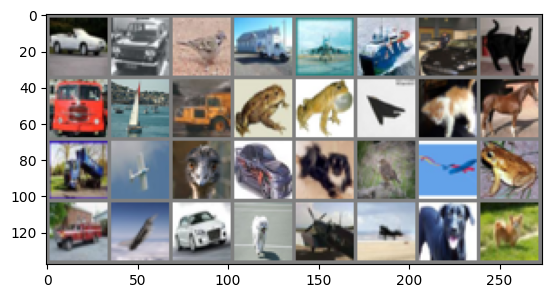

car   car   bird  truck plane ship  car   cat   truck ship  truck frog  frog  plane cat   horse truck plane bird  car   dog   bird  plane frog  truck plane car   dog   plane plane dog   dog  


In [ ]:
# use torchvision to load Cifar10 image datasets.
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# function to preprocess cifar10 images
transform = torchvision.transforms.Compose(
    [torchvision.transforms.RandomHorizontalFlip(),
     torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

# function to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


batch_size = 32

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"number of images in the training set: {len(trainset)}")
print(f"number of images in the test set: {len(testset)}")
print(f"size of first image in the training set = {trainset[0][0].shape}, its label = {classes[trainset[0][1]]}")

# display images in the first batch and their labels
dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

# define CNN structure and its forward pass layer-by-layer
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Conv2d(in_channels=3,out_channels=64,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64,out_channels=64,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2,stride = 2),

            nn.Conv2d(in_channels=64,out_channels=128,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128,out_channels=128,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2,stride = 2),

            nn.Conv2d(in_channels=128,out_channels=256,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256,out_channels=256,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256,out_channels=256,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2,stride = 2),


            nn.Flatten(),
            nn.Linear(256*4*4, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
            ]
        )
    def forward(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)

        loss.backward()
        optimizer.step()
        if batch_idx % 1000 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [ ]:
device = torch.device("cuda")

model = Net().to(device)

optimizer= torch.optim.SGD(model.parameters(), lr=0.05)
scheduler = StepLR(optimizer, step_size=1, gamma=0.9)

for epoch in range(1, 21):
  train(model, device, trainloader, optimizer, epoch)
  test(model, device, testloader)
  scheduler.step()


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Train Epoch: 1 [0/50000 (0%)]	Loss: 2.300526
Train Epoch: 1 [32000/50000 (64%)]	Loss: 2.307765


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()



Test set: Average loss: 2.3029, Accuracy: 1152/10000 (12%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 2.297933
Train Epoch: 2 [32000/50000 (64%)]	Loss: 2.305972

Test set: Average loss: 2.2061, Accuracy: 1870/10000 (19%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 2.252109
Train Epoch: 3 [32000/50000 (64%)]	Loss: 1.970737

Test set: Average loss: 1.9298, Accuracy: 2958/10000 (30%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 2.406537
Train Epoch: 4 [32000/50000 (64%)]	Loss: 1.692255

Test set: Average loss: 1.4839, Accuracy: 4488/10000 (45%)

Train Epoch: 5 [0/50000 (0%)]	Loss: 1.373850
Train Epoch: 5 [32000/50000 (64%)]	Loss: 1.405924

Test set: Average loss: 1.2746, Accuracy: 5399/10000 (54%)

Train Epoch: 6 [0/50000 (0%)]	Loss: 1.149336
Train Epoch: 6 [32000/50000 (64%)]	Loss: 0.985044

Test set: Average loss: 1.2861, Accuracy: 5544/10000 (55%)

Train Epoch: 7 [0/50000 (0%)]	Loss: 0.979172
Train Epoch: 7 [32000/50000 (64%)]	Loss: 0.957684

Test set: Average loss: 0.9346, Accuracy: 6690/10000 (67%)

Tra

After 20 training epochs, the CNN achieved the highest test accuracy of 82% on the dataset. This was the best test performance I was able to obtain while keeping the model structure similar to the CNN model in Figure 8.23.

This model demonstrates reasonable generalization, as it performs well on unseen test images. However, it can probably perform better with additional modifications to the model, such as incorporating data augmentation, batch normalization or dropout layers between fully connected layers to reduce overfitting and enhance performance.